In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc

In [58]:
df = pd.read_csv("data.csv")
df

,date,precipitation,temp_max,temp_min,wind,weather
0,1/1/2012,0.0,12.8,5.0,4.7,drizzle
1,1/2/2012,10.9,10.6,2.8,4.5,rain
2,1/3/2012,0.8,11.7,7.2,2.3,rain
3,1/4/2012,20.3,12.2,5.6,4.7,rain
4,1/5/2012,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,12/27/2015,8.6,4.4,1.7,2.9,rain
1457,12/28/2015,1.5,5.0,1.7,1.3,rain
1458,12/29/2015,0.0,7.2,0.6,2.6,fog
1459,12/30/2015,0.0,5.6,-1.0,3.4,sun


In [59]:
# quitar
df = df.drop(columns = ['date'])

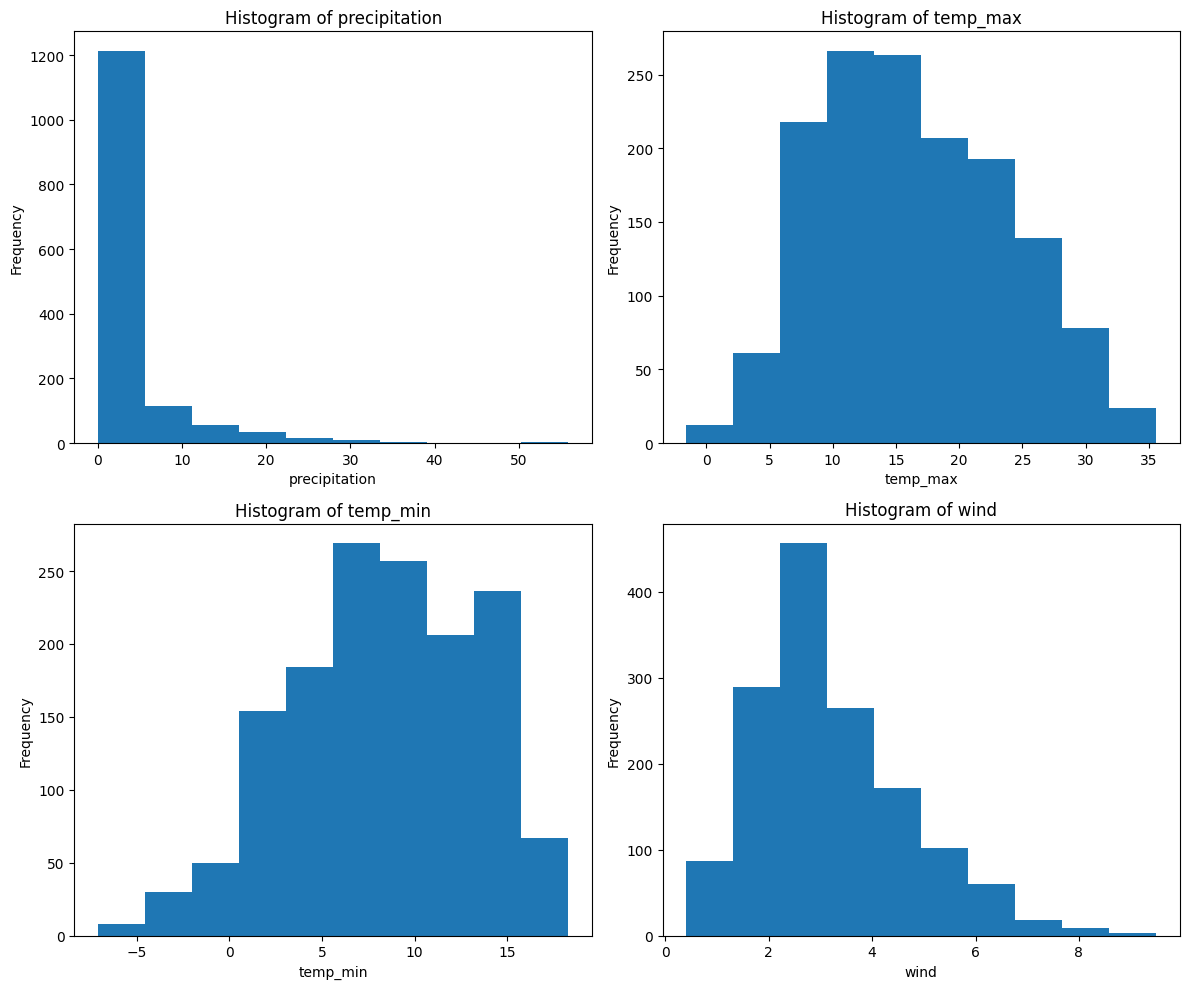

In [60]:
numerical_cols = ['precipitation', 'temp_max', 'temp_min', 'wind']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col])
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [61]:
# Identificamos de nulos
df.isnull().sum()

,0
precipitation,0
temp_max,0
temp_min,0
wind,0
weather,0


# Identificación de misbalance

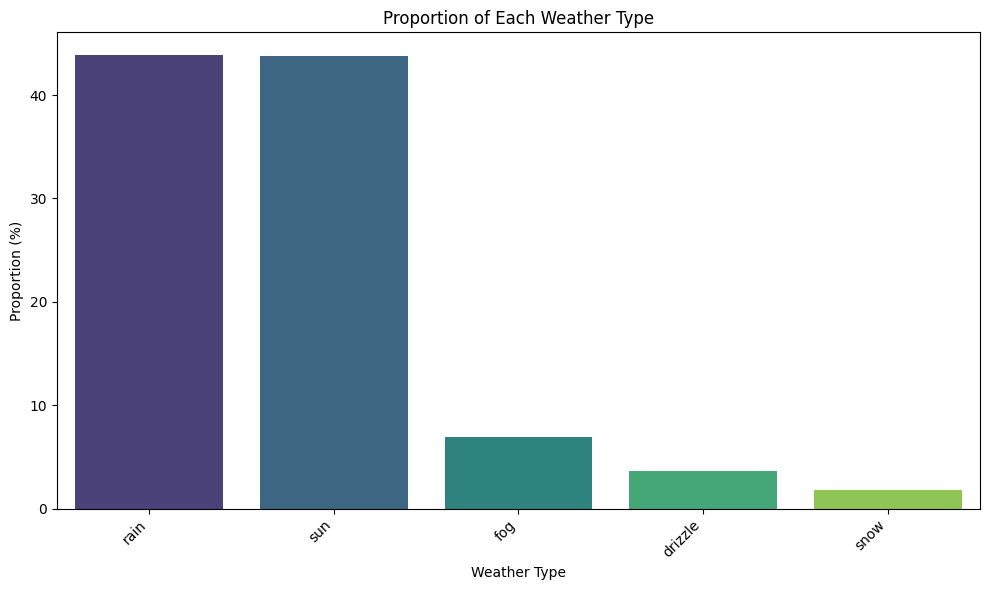

In [62]:
weather_counts = df['weather'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=weather_counts.index, y=weather_counts.values, hue=weather_counts.index, palette='viridis', legend=False)
plt.title('Proportion of Each Weather Type')
plt.xlabel('Weather Type')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Existe un misbalance debido a que la proporción de los datos máximos son más de 4 veces de los datos menores. Los datos de fog, dizzle y snow representan menos del 10% dataset; mientras que rain y sun presentan un poco más del 40%.

In [63]:
print("Original class dsitribution:")
Counter(df['weather'])

Original class dsitribution:


Counter({'drizzle': 53, 'rain': 641, 'sun': 640, 'snow': 26, 'fog': 101})

In [64]:
X = df.drop('weather', axis = 1)
Y = df['weather']

In [65]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42)

In [66]:
ros = RandomOverSampler(random_state=42)
X_train_balanced, Y_train_balanced = ros.fit_resample(X_train, Y_train)

In [67]:
Counter(Y_train_balanced)

Counter({'rain': 449, 'sun': 449, 'fog': 449, 'drizzle': 449, 'snow': 449})

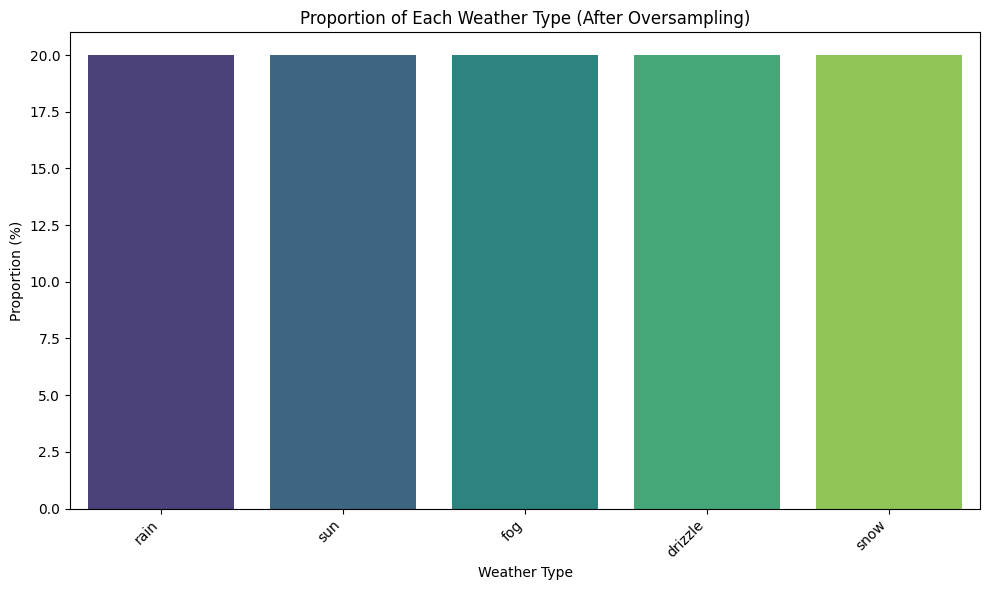

In [68]:
weather_counts_balanced = Y_train_balanced.value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=weather_counts_balanced.index, y=weather_counts_balanced.values, hue=weather_counts_balanced.index, palette='viridis', legend=False)
plt.title('Proportion of Each Weather Type (After Oversampling)')
plt.xlabel('Weather Type')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Decision Tree a mano

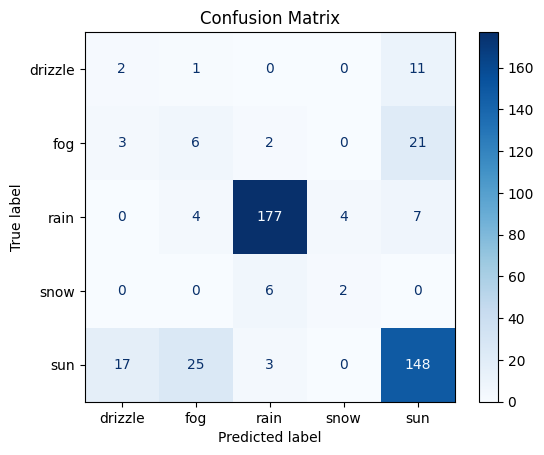

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.09      0.14      0.11        14
         fog       0.17      0.19      0.18        32
        rain       0.94      0.92      0.93       192
        snow       0.33      0.25      0.29         8
         sun       0.79      0.77      0.78       193

    accuracy                           0.76       439
   macro avg       0.46      0.45      0.46       439
weighted avg       0.78      0.76      0.77       439



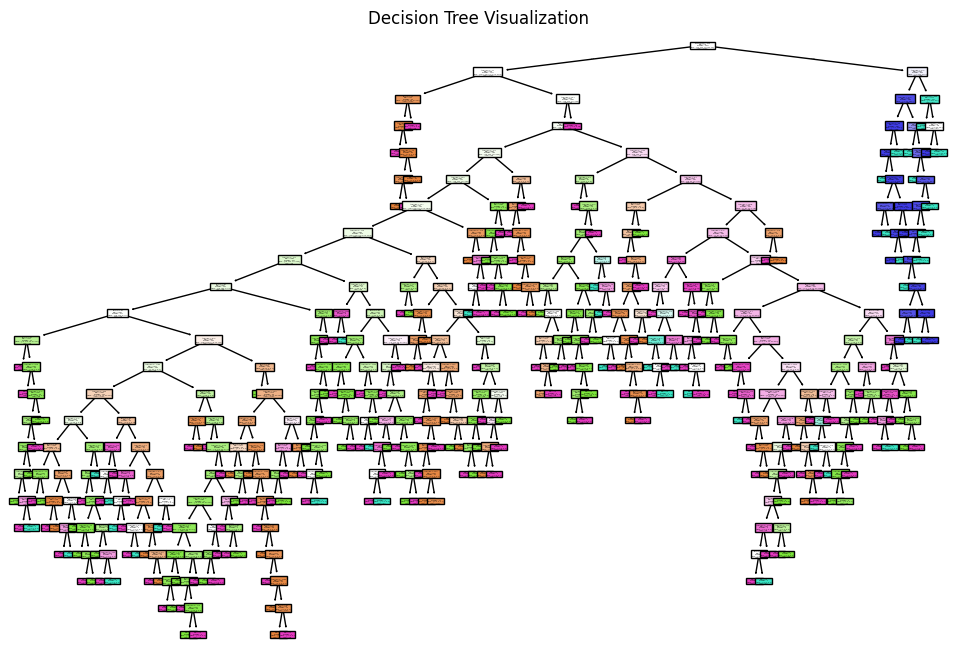

In [69]:
# Initialize and train Decision Tree classifier
clf = DecisionTreeClassifier()
clf.fit(X_train_balanced, Y_train_balanced)



# Predict on test data
y_pred = clf.predict(X_test)

# Confusion matrix
cm = confusion_matrix(Y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Classification report
report = classification_report(Y_test, y_pred, labels=clf.classes_)
print("Classification Report:")
print(report)

#Visualize decision tree
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

# Optimización de hiperparámetros

## Sin oversampling

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Best Hyperparmeters:  DecisionTreeClassifier(max_depth=4, max_leaf_nodes=20, min_samples_leaf=4,
                       random_state=42)


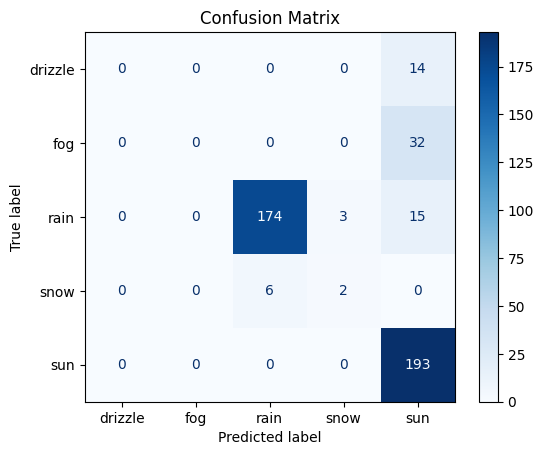

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

     drizzle       0.00      0.00      0.00        14
         fog       0.00      0.00      0.00        32
        rain       0.97      0.91      0.94       192
        snow       0.40      0.25      0.31         8
         sun       0.76      1.00      0.86       193

    accuracy                           0.84       439
   macro avg       0.43      0.43      0.42       439
weighted avg       0.76      0.84      0.79       439



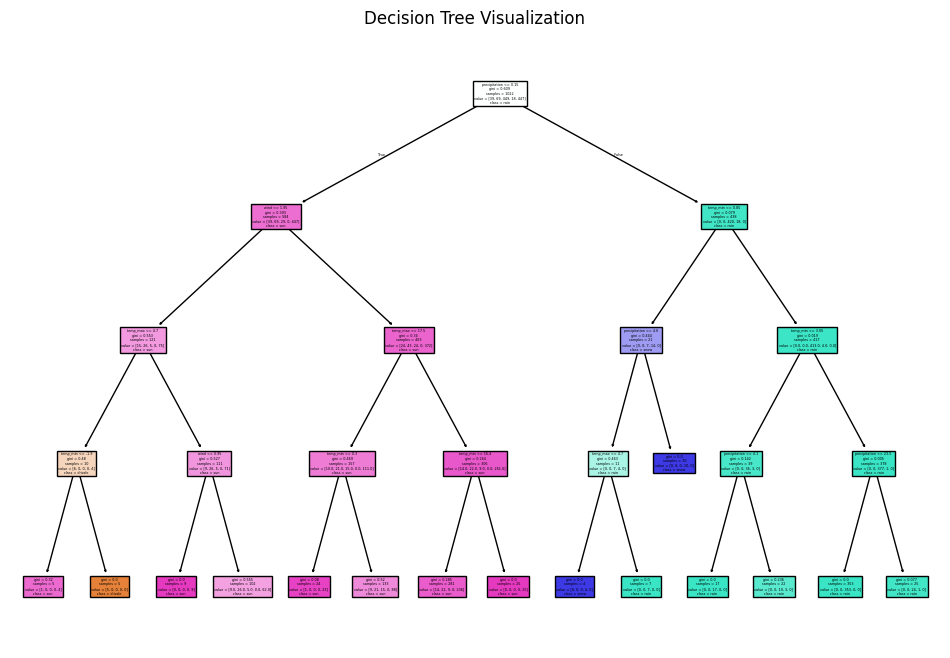

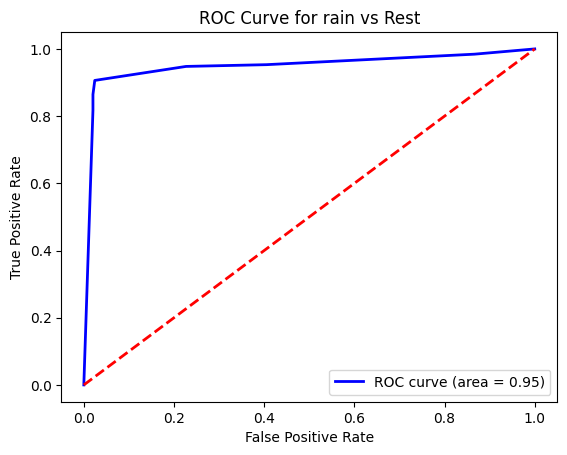

In [70]:
# Initialize and train Decision Tree classifier
dtree = DecisionTreeClassifier(random_state=42)
param_grid = {
  'max_depth' : [2, 3, 4, 5, None],
  'min_samples_split' : [2, 4, 6, 10],
  'min_samples_leaf' : [1, 2, 4],
  'max_features' : [None, 'sqrt', 'log2'],
  'max_leaf_nodes' : [None, 5, 10, 20]
}

grid_search = GridSearchCV(estimator=dtree, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs = -1, verbose = 1)
grid_search.fit(X_train, Y_train)

best_model = grid_search.best_estimator_
print("Best Hyperparmeters: ", best_model)

y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(Y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


report = classification_report(Y_test, y_pred, labels=best_model.classes_)
print("Classification Report:")
print(report)

plt.figure(figsize=(12, 8))
plot_tree(best_model, feature_names=X.columns, class_names=best_model.classes_, filled = True)
plt.title("Decision Tree Visualization")
plt.show()


possitive_class = 'rain'
y_test_binary = (Y_test == possitive_class).astype(int)
y_score = best_model.predict_proba(X_test)[:, list(best_model.classes_).index(possitive_class)]
fpr, tpr, thresholds = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for {possitive_class} vs Rest')
plt.legend(loc='lower right')
plt.show()


## Con oversamling

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Best Hyperparmeters:  DecisionTreeClassifier(max_features='sqrt', random_state=42)


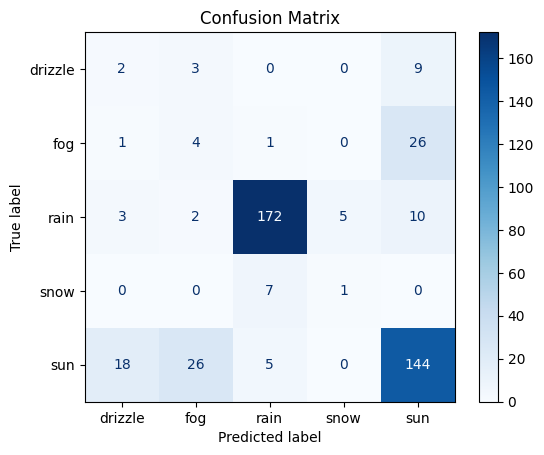

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.08      0.14      0.11        14
         fog       0.11      0.12      0.12        32
        rain       0.93      0.90      0.91       192
        snow       0.17      0.12      0.14         8
         sun       0.76      0.75      0.75       193

    accuracy                           0.74       439
   macro avg       0.41      0.41      0.41       439
weighted avg       0.76      0.74      0.75       439



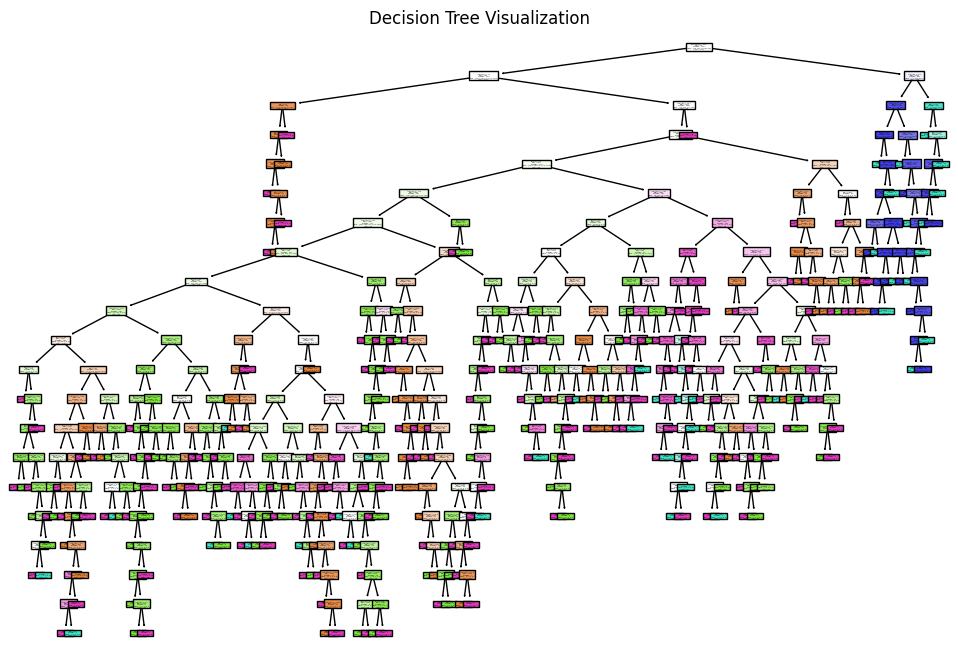

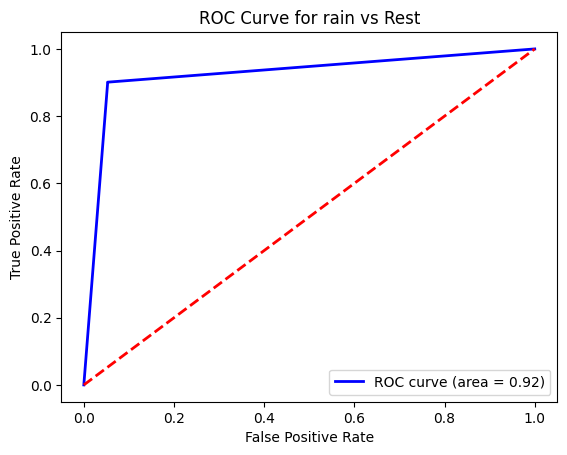

In [71]:
# Initialize and train Decision Tree classifier
dtree = DecisionTreeClassifier(random_state=42)
param_grid = {
  'max_depth' : [2, 3, 4, 5, None],
  'min_samples_split' : [2, 4, 6, 10],
  'min_samples_leaf' : [1, 2, 4],
  'max_features' : [None, 'sqrt', 'log2'],
  'max_leaf_nodes' : [None, 5, 10, 20]
}

grid_search = GridSearchCV(estimator=dtree, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs = -1, verbose = 1)
grid_search.fit(X_train_balanced, Y_train_balanced)

best_model = grid_search.best_estimator_
print("Best Hyperparmeters: ", best_model)

y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(Y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


report = classification_report(Y_test, y_pred, labels=best_model.classes_)
print("Classification Report:")
print(report)

plt.figure(figsize=(12, 8))
plot_tree(best_model, feature_names=X.columns, class_names=best_model.classes_, filled = True)
plt.title("Decision Tree Visualization")
plt.show()


possitive_class = 'rain'
y_test_binary = (Y_test == possitive_class).astype(int)
y_score = best_model.predict_proba(X_test)[:, list(best_model.classes_).index(possitive_class)]
fpr, tpr, thresholds = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for {possitive_class} vs Rest')
plt.legend(loc='lower right')
plt.show()
